In [1]:
select_lineitem_csv_data = """timing types	count	Total Time (ns)
network ops & mem copy	59986053	8104853026
de/serialization	59986053	39432896558
DB internal ops	1	270800"""

copy_from_csv_data = """timing types	count	Total Time (ns)
network ops & mem copy	1469957	38727411804
de/serialization	59986053	52591897638
DB internal ops	179958156	32676754969"""

copy_to_csv_data = """timing types	count	Total Time (ns)
network ops & mem copy	1	10739570021
de/serialization	59986052	42305450119
DB internal ops	2	407131"""

In [2]:
# load as pandas dataframe
import pandas as pd
from io import StringIO

UNI_FONTSIZE = 20

select_lineitem_df = pd.read_csv(StringIO(select_lineitem_csv_data), sep="\t")
copy_from_df = pd.read_csv(StringIO(copy_from_csv_data), sep="\t")
copy_to_df = pd.read_csv(StringIO(copy_to_csv_data), sep="\t")

# print(select_lineitem_df)


Percentage Breakdown:
------------------------------------------------------------

select_lineitem:
  network ops & mem copy: 17.05%
  de/serialization: 82.95%
  DB internal ops: 0.00%

copy_from:
  network ops & mem copy: 31.23%
  de/serialization: 42.41%
  DB internal ops: 26.35%

copy_to:
  network ops & mem copy: 20.25%
  de/serialization: 79.75%
  DB internal ops: 0.00%


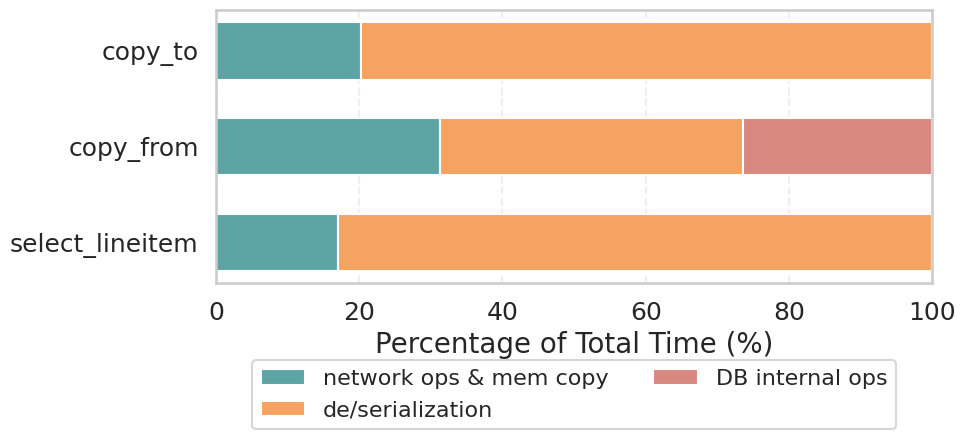

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting - calculate percentages for each query
def prepare_plot_data(df, query_name):
    """
    Calculate percentage of total time for each timing type.
    
    Args:
        df: DataFrame with columns 'timing types', 'count', 'Total Time (ns)'
        query_name: Name of the query for labeling
    
    Returns:
        Dictionary with timing type percentages
    """
    total_time = df['Total Time (ns)'].sum()
    percentages = {}
    for _, row in df.iterrows():
        timing_type = row['timing types']
        percentage = (row['Total Time (ns)'] / total_time) * 100
        percentages[timing_type] = percentage
    percentages['query'] = query_name
    return percentages

# Calculate percentages for each query
select_data = prepare_plot_data(select_lineitem_df, 'select_lineitem')
copy_from_data = prepare_plot_data(copy_from_df, 'copy_from')
copy_to_data = prepare_plot_data(copy_to_df, 'copy_to')

# Combine into a list for plotting
plot_data = [select_data, copy_from_data, copy_to_data]

# Extract data for stacked bar chart
queries = [d['query'] for d in plot_data]
network_percentages = [d.get('network ops & mem copy', 0) for d in plot_data]
deserialization_percentages = [d.get('de/serialization', 0) for d in plot_data]
db_internal_percentages = [d.get('DB internal ops', 0) for d in plot_data]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Set color palette - using distinct colors for each timing type
colors = ['#5da5a5', '#f4a460', '#d98880']  # teal, sandy brown, light coral

# Create horizontal stacked bar chart
y_pos = np.arange(len(queries))

# Plot each component of the stacked bar
# Start with network ops & mem copy (leftmost)
bars1 = ax.barh(y_pos, network_percentages, color=colors[0], 
                label='network ops & mem copy', height=0.6)

# Add de/serialization (middle section)
bars2 = ax.barh(y_pos, deserialization_percentages, 
                left=network_percentages, color=colors[1], 
                label='de/serialization', height=0.6)

# Add DB internal ops (rightmost)
bars3 = ax.barh(y_pos, db_internal_percentages, 
                left=[network_percentages[i] + deserialization_percentages[i] 
                      for i in range(len(queries))],
                color=colors[2], label='DB internal ops', height=0.6)

# Customize the plot
ax.set_xlabel('Percentage of Total Time (%)', fontsize=UNI_FONTSIZE)
# ax.set_ylabel('Query Type', fontsize=UNI_FONTSIZE)
ax.set_yticks(y_pos)
ax.set_yticklabels(queries, fontsize=UNI_FONTSIZE-2)
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))
ax.tick_params(axis='x', labelsize=UNI_FONTSIZE-2)

# Add legend
# ax.legend(loc='upper right', fontsize=UNI_FONTSIZE-4, frameon=True)

ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.24),
    fontsize=UNI_FONTSIZE-4,
    frameon=True,
    ncol=2  # display legend entries in a single row
)

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Tight layout to prevent label cutoff
plt.tight_layout()

plt.savefig('./plots/timing_percentage.pdf')
# Display the plot
# plt.show()


# Optional: Print percentage breakdown for verification
print("\nPercentage Breakdown:")
print("-" * 60)
for data in plot_data:
    print(f"\n{data['query']}:")
    print(f"  network ops & mem copy: {data.get('network ops & mem copy', 0):.2f}%")
    print(f"  de/serialization: {data.get('de/serialization', 0):.2f}%")
    print(f"  DB internal ops: {data.get('DB internal ops', 0):.2f}%")


Raw Timing Breakdown (milliseconds):
------------------------------------------------------------

select_lineitem:
  network ops & mem copy: 8104.85 ms
  de/serialization: 39432.90 ms
  DB internal ops: 0.27 ms
  Total: 47538.02 ms

copy_from:
  network ops & mem copy: 38727.41 ms
  de/serialization: 52591.90 ms
  DB internal ops: 32676.75 ms
  Total: 123996.06 ms

copy_to:
  network ops & mem copy: 10739.57 ms
  de/serialization: 42305.45 ms
  DB internal ops: 0.41 ms
  Total: 53045.43 ms


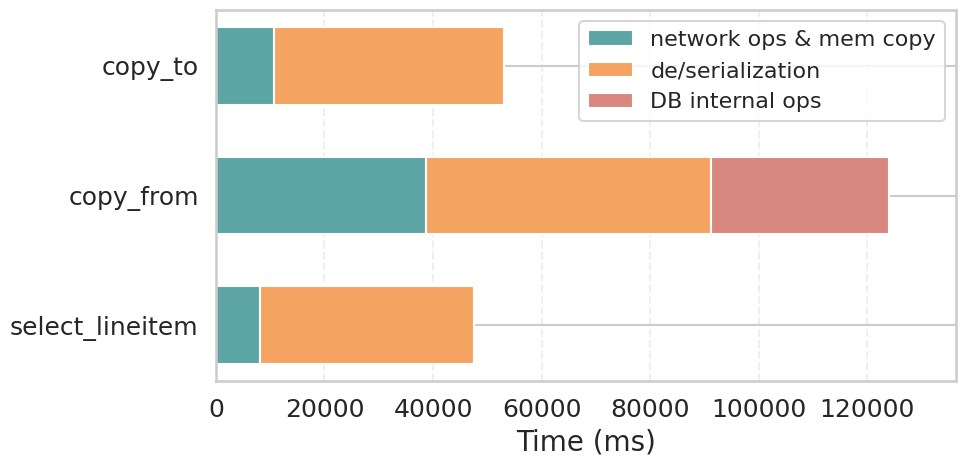

In [28]:
# Prepare data for plotting - calculate percentages or extract raw timing values
def prepare_plot_data(df, query_name, use_percentage=True):
    """
    Calculate percentage of total time for each timing type, or extract raw timing values.

    Args:
        df: DataFrame with columns 'timing types', 'count', 'Total Time (ns)'
        query_name: Name of the query for labeling
        use_percentage: If True, calculate percentages; if False, use raw timing in milliseconds

    Returns:
        Dictionary with timing type percentages or raw timing values in milliseconds
    """
    if use_percentage:
        # Calculate percentages as before
        total_time = df['Total Time (ns)'].sum()
        percentages = {}
        for _, row in df.iterrows():
            timing_type = row['timing types']
            percentage = (row['Total Time (ns)'] / total_time) * 100
            percentages[timing_type] = percentage
        percentages['query'] = query_name
        return percentages
    else:
        # Extract raw timing values and convert from nanoseconds to milliseconds
        timings = {}
        for _, row in df.iterrows():
            timing_type = row['timing types']
            # Convert nanoseconds to milliseconds (divide by 1,000,000)
            time_ms = row['Total Time (ns)'] / 1_000_000.0
            timings[timing_type] = time_ms
        timings['query'] = query_name
        return timings

# Calculate percentages or raw timings for each query based on plot_percentage flag
select_data = prepare_plot_data(select_lineitem_df, 'select_lineitem', use_percentage=plot_percentage)
copy_from_data = prepare_plot_data(copy_from_df, 'copy_from', use_percentage=plot_percentage)
copy_to_data = prepare_plot_data(copy_to_df, 'copy_to', use_percentage=plot_percentage)

# Combine into a list for plotting
plot_data = [select_data, copy_from_data, copy_to_data]

# Extract data for stacked bar chart
queries = [d['query'] for d in plot_data]
network_percentages = [d.get('network ops & mem copy', 0) for d in plot_data]
deserialization_percentages = [d.get('de/serialization', 0) for d in plot_data]
db_internal_percentages = [d.get('DB internal ops', 0) for d in plot_data]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Set color palette - using distinct colors for each timing type
colors = ['#5da5a5', '#f4a460', '#d98880']  # teal, sandy brown, light coral

# Create horizontal stacked bar chart
y_pos = np.arange(len(queries))

# Plot each component of the stacked bar
# Start with network ops & mem copy (leftmost)
bars1 = ax.barh(y_pos, network_percentages, color=colors[0], 
                label='network ops & mem copy', height=0.6)

# Add de/serialization (middle section)
bars2 = ax.barh(y_pos, deserialization_percentages, 
                left=network_percentages, color=colors[1], 
                label='de/serialization', height=0.6)

# Add DB internal ops (rightmost)
bars3 = ax.barh(y_pos, db_internal_percentages, 
                left=[network_percentages[i] + deserialization_percentages[i] 
                      for i in range(len(queries))],
                color=colors[2], label='DB internal ops', height=0.6)

# Customize the plot - adjust labels and limits based on plot_percentage
if plot_percentage:
    ax.set_xlabel('Percentage of Total Time (%)', fontsize=UNI_FONTSIZE)
    ax.set_xlim(0, 100)
    ax.set_xticks(np.arange(0, 101, 20))
else:
    ax.set_xlabel('Time (ms)', fontsize=UNI_FONTSIZE)
    # For raw timing, set x-axis limits dynamically based on max value
    max_time = max([sum([network_percentages[i], deserialization_percentages[i], db_internal_percentages[i]]) 
                    for i in range(len(queries))])
    ax.set_xlim(0, max_time * 1.1)  # Add 10% margin
    # Use automatic tick spacing for raw timing values
    ax.ticklabel_format(style='plain', axis='x')

# ax.set_ylabel('Query Type', fontsize=UNI_FONTSIZE)
ax.set_yticks(y_pos)
ax.set_yticklabels(queries, fontsize=UNI_FONTSIZE-2)
ax.tick_params(axis='x', labelsize=UNI_FONTSIZE-2)

# Add legend
ax.legend(loc='upper right', fontsize=UNI_FONTSIZE-4, frameon=True)

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Tight layout to prevent label cutoff
plt.tight_layout()

plt.savefig('./plots/timing_raw.pdf')
# Display the plot
# plt.show()

# Optional: Print breakdown for verification
if plot_percentage:
    print("\nPercentage Breakdown:")
    print("-" * 60)
    for data in plot_data:
        print(f"\n{data['query']}:")
        print(f"  network ops & mem copy: {data.get('network ops & mem copy', 0):.2f}%")
        print(f"  de/serialization: {data.get('de/serialization', 0):.2f}%")
        print(f"  DB internal ops: {data.get('DB internal ops', 0):.2f}%")
else:
    print("\nRaw Timing Breakdown (milliseconds):")
    print("-" * 60)
    for data in plot_data:
        print(f"\n{data['query']}:")
        print(f"  network ops & mem copy: {data.get('network ops & mem copy', 0):.2f} ms")
        print(f"  de/serialization: {data.get('de/serialization', 0):.2f} ms")
        print(f"  DB internal ops: {data.get('DB internal ops', 0):.2f} ms")
        total = (data.get('network ops & mem copy', 0) + 
                 data.get('de/serialization', 0) + 
                 data.get('DB internal ops', 0))
        print(f"  Total: {total:.2f} ms")
